# Style Classifier Improvement with Extra Training Data

## 1. Objective

The objective of this notebook is to improve the fashion style classifier by adding extra targeted training images.

The previous real-world evaluation showed that the style classifier did not generalize well to realistic images. The original style model achieved a real-world accuracy of **0.4750**, while the fine-tuned layer4 model achieved **0.4250**.

This suggests that the main issue is not only the model architecture or training strategy, but also the difference between the curated training dataset and the more varied real-world test images.

This notebook tests whether adding extra real-world-like training images improves style classification performance, especially for the weaker style categories.

## 2. Project Context

The recommendation system depends heavily on the predicted style of the input image. If the style classifier predicts the wrong style, the recommendation system retrieves items from the wrong style category.

The real-world evaluation showed that streetwear was the weakest style class. In the original real-world evaluation, streetwear had **0.00 recall**, meaning that none of the real-world streetwear images were correctly predicted as streetwear.

A later fine-tuning experiment improved curated test accuracy, but did not improve real-world accuracy. This indicated that fine-tuning alone made the model better on clean curated images, but did not solve the generalization problem.

Because of this, the next development step is dataset improvement. This notebook adds extra training images for the most problematic style and clothing type combinations.

## 3. Approach

This experiment uses the original curated style training set together with an additional targeted dataset stored in `dataset/style_extra`.

The extra dataset was created based on the real-world evaluation errors. It focuses on:

- streetwear jackets, pants, shoes, and tshirts
- formal pants and shoes
- sporty jackets and shoes

The process follows these steps:

1. Load the original style training, validation, and test sets.
2. Load the extra targeted style images.
3. Combine the original training set with the extra images.
4. Train a new ResNet34 style classifier.
5. Evaluate the model on the curated style test set.
6. Evaluate the model on the real-world test set.
7. Compare the new model with the previous style baseline and fine-tuned model.

The real-world test set is not used for training. It remains a separate external evaluation set.

## 4. Import Libraries

The notebook uses PyTorch and torchvision to train and evaluate the dataset-improved style classifier. Pandas is used to organize results, matplotlib is used for visualization, and sklearn is used for evaluation metrics such as classification reports and confusion matrices.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

torch version: 2.11.0+cu130
cuda available: True
cuda device count: 1
gpu name: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: CUDA


## 5. Dataset Paths and Results Folder

This experiment uses the original style split and the extra targeted style dataset.

The original training data comes from `dataset/split_style/train`, while the extra data comes from `dataset/style_extra`.

The model will be evaluated on:

- the curated style test set
- the separate real-world test set

A separate results folder is created for this experiment.

In [2]:
train_dir = "../dataset/split_style/train"
val_dir = "../dataset/split_style/val"
test_dir = "../dataset/split_style/test"

style_extra_dir = "../dataset/style_extra"
real_world_dir = "../dataset/real_world_test"

results_dir = "../results/style_dataset_improvement"
os.makedirs(results_dir, exist_ok=True)

model_output_path = "../models/style_resnet34_extra_data.pth"

print("Training dataset path:", train_dir)
print("Validation dataset path:", val_dir)
print("Test dataset path:", test_dir)
print("Extra style dataset path:", style_extra_dir)
print("Real-world dataset path:", real_world_dir)
print("Results folder:", results_dir)
print("Model output path:", model_output_path)

Training dataset path: ../dataset/split_style/train
Validation dataset path: ../dataset/split_style/val
Test dataset path: ../dataset/split_style/test
Extra style dataset path: ../dataset/style_extra
Real-world dataset path: ../dataset/real_world_test
Results folder: ../results/style_dataset_improvement
Model output path: ../models/style_resnet34_extra_data.pth


## 6. Image Transforms

The same base preprocessing is used as in the previous style experiments.

For the training data, light augmentation is applied using random horizontal flipping. This helps the model generalize slightly better without changing the meaning of the style labels.

The validation, curated test, extra evaluation, and real-world images use deterministic preprocessing.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 7. Load Original and Extra Training Data

The original style training dataset is loaded from `split_style/train`.

The extra targeted dataset is loaded from `style_extra`. This dataset keeps the same style/type folder structure as the cleaned dataset, so it needs to be scanned manually and loaded with a custom dataset class.

Only the style label is used for training in this notebook.

In [4]:
# Load original curated datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Original training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['formal', 'gothic', 'sporty', 'streetwear']
Original training images: 560
Validation images: 120
Test images: 120


In [5]:
class StyleExtraDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.samples = []

        valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

        for style in sorted(os.listdir(root_dir)):
            style_path = os.path.join(root_dir, style)

            if not os.path.isdir(style_path):
                continue

            if style not in class_to_idx:
                continue

            for item_type in sorted(os.listdir(style_path)):
                type_path = os.path.join(style_path, item_type)

                if not os.path.isdir(type_path):
                    continue

                for filename in sorted(os.listdir(type_path)):
                    if not filename.lower().endswith(valid_extensions):
                        continue

                    image_path = os.path.join(type_path, filename)
                    label = class_to_idx[style]

                    self.samples.append((image_path, label, style, item_type, filename))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label, style, item_type, filename = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
extra_train_dataset = StyleExtraDataset(
    root_dir=style_extra_dir,
    class_to_idx=train_dataset.class_to_idx,
    transform=train_transform
)

combined_train_dataset = ConcatDataset([
    train_dataset,
    extra_train_dataset
])

batch_size = 16

combined_train_loader = DataLoader(
    combined_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Extra training images:", len(extra_train_dataset))
print("Combined training images:", len(combined_train_dataset))

Extra training images: 100
Combined training images: 660


## 8. Dataset Overview

Before training, the distribution of the original training data, extra training data, and combined training data is checked.

This is important because the extra dataset is targeted and not evenly distributed across all classes. The goal is not to create a fully balanced extra dataset, but to strengthen the classes and item types that caused the most real-world errors.

In [7]:
def count_images_per_class_from_imagefolder(dataset):
    counts = {class_name: 0 for class_name in dataset.classes}

    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] += 1

    return counts


def count_images_per_class_from_extra_dataset(dataset, class_names):
    counts = {class_name: 0 for class_name in class_names}

    for _, label, _, _, _ in dataset.samples:
        class_name = class_names[label]
        counts[class_name] += 1

    return counts

In [8]:
original_train_counts = count_images_per_class_from_imagefolder(train_dataset)
extra_train_counts = count_images_per_class_from_extra_dataset(
    extra_train_dataset,
    class_names
)

combined_train_counts = {
    class_name: original_train_counts[class_name] + extra_train_counts[class_name]
    for class_name in class_names
}

class_distribution = pd.DataFrame({
    "Original Train": original_train_counts,
    "Extra Train": extra_train_counts,
    "Combined Train": combined_train_counts
})

class_distribution

,Original Train,Extra Train,Combined Train
formal,140,20,160
gothic,140,0,140
sporty,140,20,160
streetwear,140,60,200


## 9. Model Selection

This experiment uses the same `ResNet34` architecture as the previous style classification experiments.

To keep the experiment focused on the dataset change, the training setup is kept simple. A pretrained ResNet34 model is used, the final classification layer is replaced for the four style classes, and only the final layer is trained.

This allows the experiment to test whether adding targeted extra training data improves performance without also changing the fine-tuning strategy.

In [9]:
# Load pretrained ResNet34
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

# Replace final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

print("ResNet34 loaded.")
print("Training only the final classification layer.")

ResNet34 loaded.
Training only the final classification layer.


In [10]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)

Trainable parameters: 2052
Frozen parameters: 21284672


## 10. Training Configuration

For this dataset-improvement experiment, the model uses the same basic training setup as the original style baseline.

The main difference is the training data. Instead of using only the original curated training set, this experiment trains on the combined dataset:

- original curated style training data
- extra targeted style training data

The model is trained using:

- `CrossEntropyLoss` as the loss function
- `Adam` as the optimizer
- `10 epochs` for the first experiment

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

num_epochs = 10

print("Training setup ready.")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Number of epochs:", num_epochs)

Training setup ready.
Optimizer: Adam
Learning rate: 0.001
Number of epochs: 10


## 11. Training and Validation Loop

The model is trained using the combined training dataset.

After each epoch, the model is evaluated on the original curated validation set. This helps check whether the extra data improves learning without damaging performance on the original style split.

In [12]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_state = None

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in combined_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    if epoch_val_acc > best_val_accuracy:
        best_val_accuracy = epoch_val_acc
        best_model_state = model.state_dict()

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
    )

print("Best validation accuracy:", round(best_val_accuracy, 4))

Epoch [1/10] | Train Loss: 1.3448 | Train Acc: 0.3848 | Val Loss: 1.0830 | Val Acc: 0.5667
Epoch [2/10] | Train Loss: 0.8937 | Train Acc: 0.6924 | Val Loss: 0.7407 | Val Acc: 0.8000
Epoch [3/10] | Train Loss: 0.7086 | Train Acc: 0.7803 | Val Loss: 0.6346 | Val Acc: 0.8083
Epoch [4/10] | Train Loss: 0.6235 | Train Acc: 0.7818 | Val Loss: 0.5499 | Val Acc: 0.8417
Epoch [5/10] | Train Loss: 0.5878 | Train Acc: 0.8030 | Val Loss: 0.4888 | Val Acc: 0.8833
Epoch [6/10] | Train Loss: 0.4892 | Train Acc: 0.8470 | Val Loss: 0.4672 | Val Acc: 0.8583
Epoch [7/10] | Train Loss: 0.5014 | Train Acc: 0.8288 | Val Loss: 0.4401 | Val Acc: 0.9167
Epoch [8/10] | Train Loss: 0.4520 | Train Acc: 0.8545 | Val Loss: 0.4485 | Val Acc: 0.8500
Epoch [9/10] | Train Loss: 0.4256 | Train Acc: 0.8470 | Val Loss: 0.3860 | Val Acc: 0.9000
Epoch [10/10] | Train Loss: 0.3921 | Train Acc: 0.8803 | Val Loss: 0.3643 | Val Acc: 0.9083
Best validation accuracy: 0.9167


## 12. Load Best Validation Model

During training, the model state with the highest validation accuracy was stored.

Before evaluating on the test sets, the best validation model is loaded back into the model. This ensures that the final evaluation uses the strongest version observed during training.

In [13]:
model.load_state_dict(best_model_state)

print("Best validation model loaded.")
print("Best validation accuracy:", round(best_val_accuracy, 4))

Best validation model loaded.
Best validation accuracy: 0.9167


## 13. Training History

The training and validation curves are visualized to understand how the dataset-improved model behaved across epochs.

These plots help show whether adding extra data improved learning and whether signs of overfitting appeared during training.

### 13.1. Loss Plot

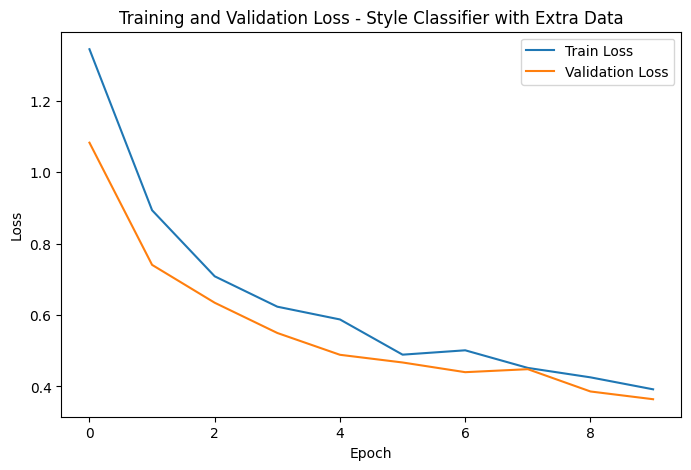

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training and Validation Loss - Style Classifier with Extra Data")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 13.2. Accuracy Plot

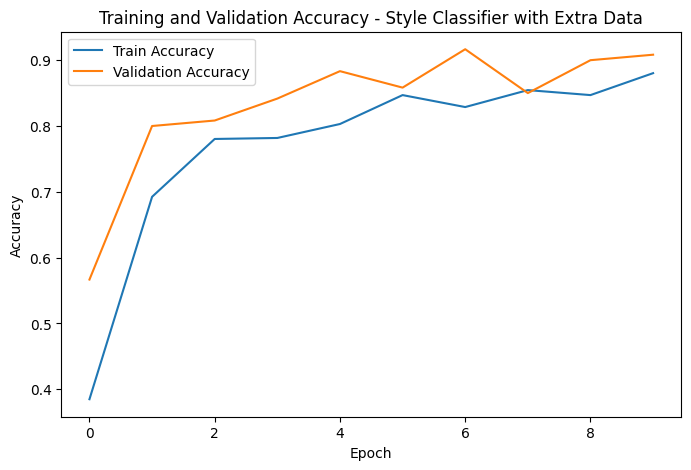

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Training and Validation Accuracy - Style Classifier with Extra Data")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 14. Curated Test Set Evaluation

After training and validation, the dataset-improved style classifier is evaluated on the curated style test set.

This test set is the same clean style test split used in the original style baseline. Evaluating on it allows the new model to be compared with the previous style experiments.

In [16]:
# Evaluate on curated test set
model.eval()

all_test_preds = []
all_test_labels = []

correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

        correct_test += (preds == labels).sum().item()
        total_test += labels.size(0)

curated_test_accuracy = correct_test / total_test

print(f"Curated Test Accuracy: {curated_test_accuracy:.4f}")

Curated Test Accuracy: 0.8667


### 14.1. Curated Test Classification Report

In [17]:
curated_test_report = classification_report(
    all_test_labels,
    all_test_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

curated_test_report_df = pd.DataFrame(curated_test_report).transpose()
curated_test_report_df

,precision,recall,f1-score,support
formal,1.000000,0.866667,0.928571,30.000000
gothic,1.000000,0.933333,0.965517,30.000000
sporty,0.774194,0.800000,0.786885,30.000000
streetwear,0.742857,0.866667,0.800000,30.000000
accuracy,0.866667,0.866667,0.866667,0.866667
macro avg,0.879263,0.866667,0.870243,120.000000
weighted avg,0.879263,0.866667,0.870243,120.000000


### 14.2. Curated Test Confusion Matrix

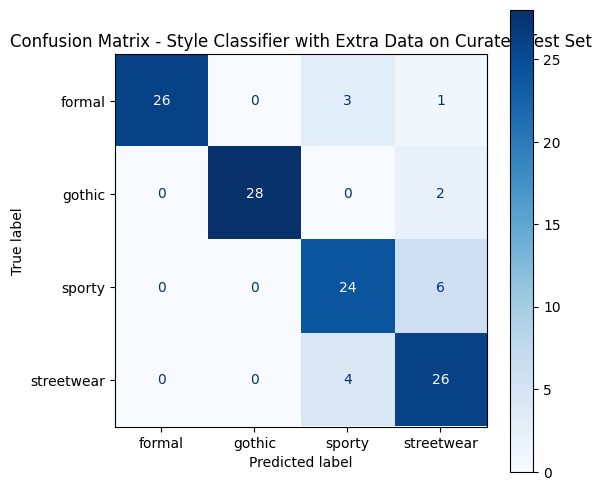

In [18]:
curated_test_cm = confusion_matrix(
    all_test_labels,
    all_test_preds
)

curated_test_disp = ConfusionMatrixDisplay(
    confusion_matrix=curated_test_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
curated_test_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Style Classifier with Extra Data on Curated Test Set")
plt.show()

## 15. Real-World Test Set Evaluation

The dataset-improved style classifier is now evaluated on the separate real-world test set.

This is the most important evaluation for this notebook because the extra training images were added specifically to improve real-world generalization.

The real-world test set is not used for training. It remains an external evaluation set.

In [19]:
valid_extensions = (".jpg", ".jpeg", ".png", ".webp")

real_world_items = []

for style in sorted(os.listdir(real_world_dir)):
    style_path = os.path.join(real_world_dir, style)

    if not os.path.isdir(style_path):
        continue

    for item_type in sorted(os.listdir(style_path)):
        type_path = os.path.join(style_path, item_type)

        if not os.path.isdir(type_path):
            continue

        for filename in sorted(os.listdir(type_path)):
            if not filename.lower().endswith(valid_extensions):
                continue

            image_path = os.path.join(type_path, filename)

            real_world_items.append({
                "image_path": image_path,
                "filename": filename,
                "true_style": style,
                "true_type": item_type
            })

real_world_df = pd.DataFrame(real_world_items)

print("Number of real-world images:", len(real_world_df))
real_world_df.head()

Number of real-world images: 80


,image_path,filename,true_style,true_type
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket
2,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_003.png,formal,jacket
3,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_004.png,formal,jacket
4,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_005.png,formal,jacket


### 15.1. Predict Real-World Styles

In [20]:
def predict_style(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()
        predicted_style = class_names[pred_idx]
        confidence = probs[0][pred_idx].item()

    return predicted_style, confidence

In [21]:
real_world_predictions = []

for _, row in real_world_df.iterrows():
    predicted_style, confidence = predict_style(row["image_path"])

    real_world_predictions.append({
        "image_path": row["image_path"],
        "filename": row["filename"],
        "true_style": row["true_style"],
        "true_type": row["true_type"],
        "predicted_style": predicted_style,
        "style_confidence": confidence
    })

real_world_predictions_df = pd.DataFrame(real_world_predictions)

real_world_predictions_df.head()

,image_path,filename,true_style,true_type,predicted_style,style_confidence
0,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_001.png,formal,jacket,formal,0.617459
1,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_002.png,formal,jacket,formal,0.752077
2,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_003.png,formal,jacket,streetwear,0.535209
3,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_004.png,formal,jacket,formal,0.669176
4,../dataset/real_world_test\formal\jacket\forma...,formal_jacket_rw_005.png,formal,jacket,formal,0.597319


### 15.2. Real-World Style Accuracy

In [22]:
real_world_style_accuracy = accuracy_score(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"]
)

print(f"Real-World Style Accuracy: {real_world_style_accuracy:.4f}")

Real-World Style Accuracy: 0.6000


### 15.3. Real-World Style Classification Report

In [23]:
real_world_style_report = classification_report(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"],
    labels=class_names,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

real_world_style_report_df = pd.DataFrame(real_world_style_report).transpose()
real_world_style_report_df

,precision,recall,f1-score,support
formal,0.866667,0.65,0.742857,20.0
gothic,0.888889,0.40,0.551724,20.0
sporty,0.750000,0.45,0.562500,20.0
streetwear,0.409091,0.90,0.562500,20.0
accuracy,0.600000,0.60,0.600000,0.6
macro avg,0.728662,0.60,0.604895,80.0
weighted avg,0.728662,0.60,0.604895,80.0


### 15.4. Real-World Style Confusion Matrix

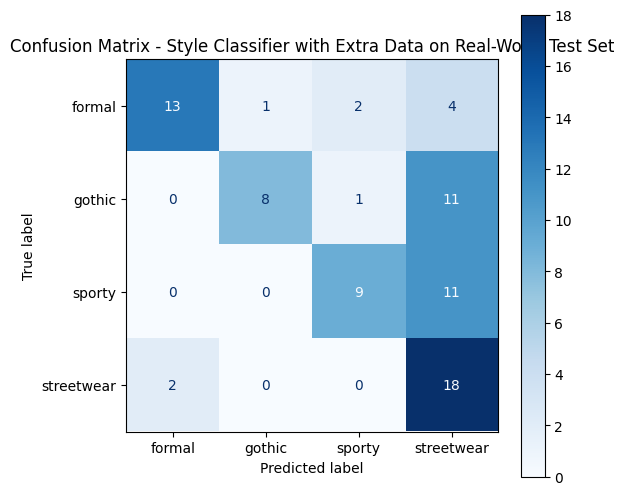

In [24]:
real_world_style_cm = confusion_matrix(
    real_world_predictions_df["true_style"],
    real_world_predictions_df["predicted_style"],
    labels=class_names
)

real_world_style_disp = ConfusionMatrixDisplay(
    confusion_matrix=real_world_style_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 6))
real_world_style_disp.plot(cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Style Classifier with Extra Data on Real-World Test Set")
plt.show()

## 16. Comparison with Previous Style Models

The dataset-improved model is compared with the previous style models.

The comparison includes:

- the original style baseline
- the fine-tuned layer4 style model
- the dataset-improved style model

This helps show whether adding targeted extra training data improved real-world generalization.

In [25]:
comparison_df = pd.DataFrame([
    {
        "Model": "Original style baseline",
        "Training strategy": "Frozen feature extractor, trained final layer",
        "Extra data": "No",
        "Curated test accuracy": 0.8417,
        "Real-world test accuracy": 0.4750
    },
    {
        "Model": "Fine-tuned layer4 model",
        "Training strategy": "Fine-tuned layer4 and final layer",
        "Extra data": "No",
        "Curated test accuracy": 0.9417,
        "Real-world test accuracy": 0.4250
    },
    {
        "Model": "Dataset-improved model",
        "Training strategy": "Frozen feature extractor, trained final layer",
        "Extra data": "Yes",
        "Curated test accuracy": curated_test_accuracy,
        "Real-world test accuracy": real_world_style_accuracy
    }
])

comparison_df

,Model,Training strategy,Extra data,Curated test accuracy,Real-world test accuracy
0,Original style baseline,"Frozen feature extractor, trained final layer",No,0.841700,0.475
1,Fine-tuned layer4 model,Fine-tuned layer4 and final layer,No,0.941700,0.425
2,Dataset-improved model,"Frozen feature extractor, trained final layer",Yes,0.866667,0.600


## 17. Inspect Incorrect Real-World Predictions

The incorrect real-world predictions are inspected to understand where the dataset-improved model still fails.

This is important because the real-world accuracy improved, but the confusion matrix shows that the model now predicts streetwear too often.

In [26]:
incorrect_real_world_df = real_world_predictions_df[
    real_world_predictions_df["true_style"] != real_world_predictions_df["predicted_style"]
].copy()

print("Incorrect real-world style predictions:", len(incorrect_real_world_df))

incorrect_real_world_df[
    ["filename", "true_style", "predicted_style", "style_confidence", "true_type"]
]

Incorrect real-world style predictions: 32


,filename,true_style,predicted_style,style_confidence,true_type
2,formal_jacket_rw_003.png,formal,streetwear,0.535209,jacket
11,formal_shoes_rw_002.png,formal,gothic,0.317729,shoes
15,formal_tshirt_rw_001.png,formal,streetwear,0.418346,tshirt
16,formal_tshirt_rw_002.png,formal,streetwear,0.868595,tshirt
17,formal_tshirt_rw_003.png,formal,sporty,0.501205,tshirt
18,formal_tshirt_rw_004.png,formal,sporty,0.514576,tshirt
19,formal_tshirt_rw_005.png,formal,streetwear,0.582799,tshirt
21,gothic_jacket_rw_002.png,gothic,streetwear,0.573251,jacket
22,gothic_jacket_rw_003.png,gothic,streetwear,0.441388,jacket
24,gothic_jacket_rw_005.png,gothic,streetwear,0.547886,jacket


### 17.1. Visualize Incorrect Real-World Predictions

In [27]:
def show_style_prediction_examples(df, title, max_images=8):
    if len(df) == 0:
        print("No examples to show.")
        return

    sample_df = df.head(max_images)

    cols = min(len(sample_df), 4)
    rows = int(np.ceil(len(sample_df) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    if rows == 1 and cols == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(image)
        axes[i].set_title(
            f"True: {row['true_style']}\n"
            f"Pred: {row['predicted_style']} ({row['style_confidence']:.2f})\n"
            f"Type: {row['true_type']}"
        )
        axes[i].axis("off")

    for j in range(len(sample_df), len(axes)):
        axes[j].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

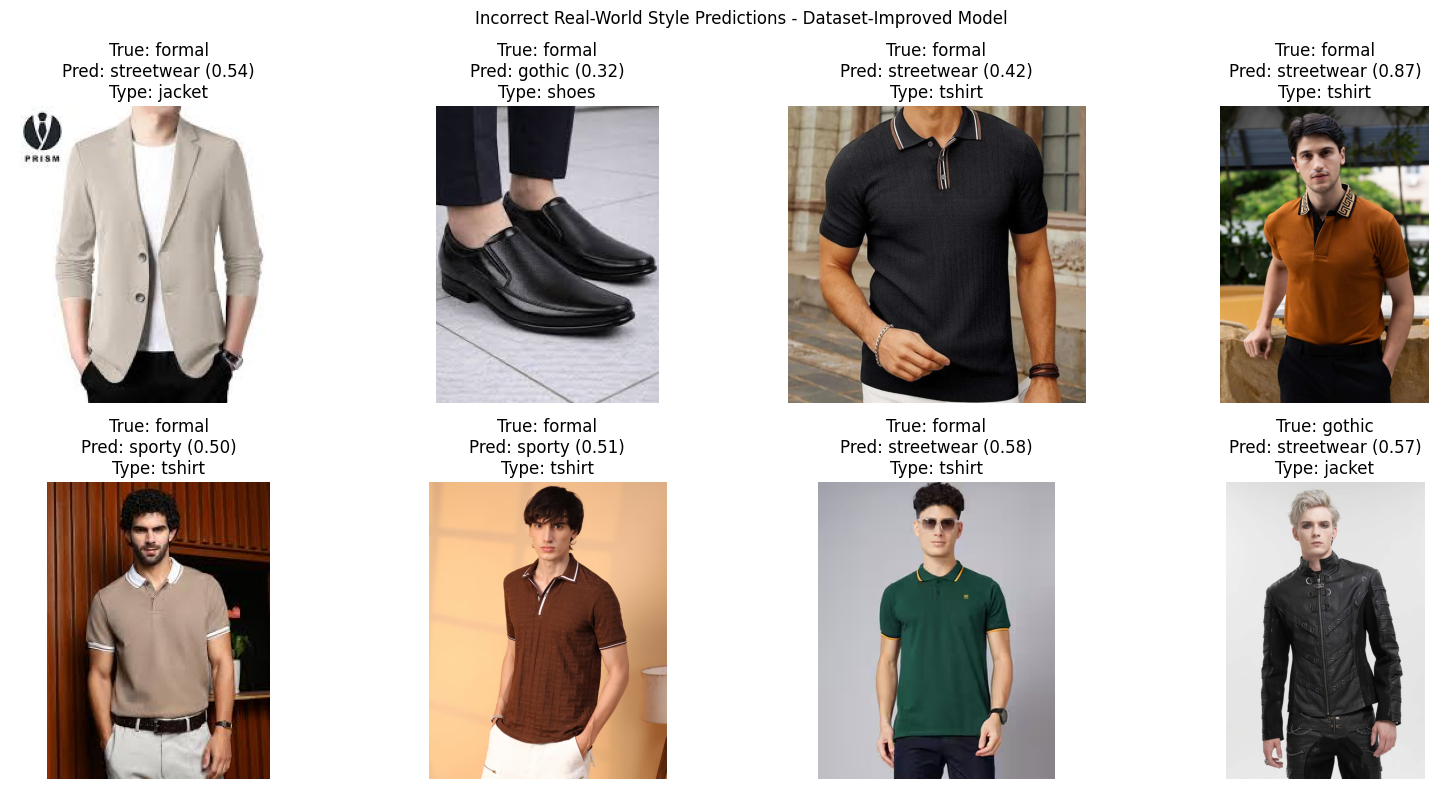

In [28]:
show_style_prediction_examples(
    incorrect_real_world_df,
    "Incorrect Real-World Style Predictions - Dataset-Improved Model"
)

## 18. Results Interpretation

The dataset-improved style model achieved a curated test accuracy of **0.8667** and a real-world style accuracy of **0.6000**.

Compared with the original style baseline, the curated test accuracy improved from **0.8417** to **0.8667**. More importantly, the real-world accuracy improved from **0.4750** to **0.6000**. This shows that adding targeted extra training data had a positive effect on generalization.

This result is especially important because the previous fine-tuning experiment improved curated test accuracy but reduced real-world accuracy. In contrast, this dataset-improvement experiment produced a better real-world result, which suggests that the main issue was dataset mismatch rather than only model architecture.

The biggest improvement is visible in the **streetwear** class. In the original real-world evaluation, streetwear had **0.00 recall**. In the fine-tuned layer4 experiment, streetwear recall was only **0.05**. In this dataset-improved model, streetwear recall increased to **0.90**. This means the extra streetwear images helped the model recognize streetwear much more reliably.

However, this improvement created a new issue. The model now predicts streetwear too often. This is visible in the confusion matrix and incorrect prediction table, where many gothic and sporty images were predicted as streetwear. For example, several gothic jackets, pants, shoes, and tshirts were classified as streetwear. Sporty shoes were also often predicted as streetwear.

This means the extra dataset helped the model learn streetwear features, but it also shifted the model too strongly toward the streetwear class. Streetwear precision is only **0.4091**, while recall is **0.90**. In other words, the model now catches most streetwear images, but many of its streetwear predictions are false positives.

Overall, this experiment is successful because it improved the main real-world weakness of the previous models. At the same time, it shows that the next improvement should focus on balancing the extra dataset and adding clearer boundary examples between streetwear, gothic, and sporty.

## 19. Limitations

This experiment has several limitations.

First, the extra dataset was targeted rather than fully balanced. Most extra images were added for streetwear because it was the weakest class in the previous evaluation. This helped streetwear recall, but it also caused the model to predict streetwear too often.

Second, the extra dataset contained only **100 images**. This was enough to improve real-world accuracy, but it is still small for image classification. A larger and more balanced dataset would likely produce more stable results.

Third, the model was trained only by updating the final classification layer. This kept the experiment comparable to the original baseline, but it may limit how much the model can adapt to more complex fashion-specific features.

Fourth, style classification remains subjective. Some gothic, sporty, and streetwear items share visual features such as dark colors, oversized shapes, sneakers, or urban styling. This makes the boundary between these classes difficult.

Finally, the real-world test set contains only **80 images**, so the results should be treated as a useful development signal rather than a final benchmark.

## 20. Conclusion

This notebook tested whether adding targeted extra training data could improve the style classifier.

The dataset-improved model achieved a curated test accuracy of **0.8667** and a real-world style accuracy of **0.6000**. This is the best real-world style result so far.

Compared with the original style baseline, real-world accuracy improved from **0.4750** to **0.6000**. Compared with the fine-tuned layer4 model, real-world accuracy improved from **0.4250** to **0.6000**.

The most important improvement was the streetwear class. Streetwear recall increased from **0.00** in the original real-world evaluation to **0.90** in this experiment. This confirms that adding more varied streetwear training examples helped the model recognize streetwear better.

However, the model now overpredicts streetwear. Many gothic and sporty items were incorrectly classified as streetwear. This means the next improvement should not simply add more streetwear images. Instead, the dataset should be improved with clearer boundary examples, especially:

- gothic items that should not be classified as streetwear
- sporty shoes and jackets that should not be classified as streetwear
- streetwear examples that are visually distinct from gothic and sporty

Overall, this experiment shows that dataset improvement is a more effective direction than fine-tuning alone for improving real-world generalization. The next development step should focus on dataset balancing and clearer style boundaries.

## 21. Saving the Results

The dataset-improved model, training history, curated test results, real-world test results, and comparison summary are saved to separate files.

This keeps the experiment reproducible and makes it easier to compare against the original style baseline and the fine-tuned layer4 model.

### 21.1. Save Dataset-Improved Model

In [29]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "training_strategy": "frozen_feature_extractor_trained_final_layer_with_extra_data",
    "curated_test_accuracy": curated_test_accuracy,
    "real_world_style_accuracy": real_world_style_accuracy,
    "extra_training_images": len(extra_train_dataset),
    "combined_training_images": len(combined_train_dataset)
}, model_output_path)

print("Dataset-improved style model saved.")

Dataset-improved style model saved.


### 21.2. Save Training History

In [30]:
training_history = pd.DataFrame({
    "epoch": range(1, num_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accuracies,
    "val_accuracy": val_accuracies
})

training_history.to_csv(
    os.path.join(results_dir, "style_extra_data_training_history.csv"),
    index=False
)

### 21.3. Save Curated Test Results

In [31]:
curated_test_report_df.to_csv(
    os.path.join(results_dir, "style_extra_data_curated_test_classification_report.csv")
)

pd.DataFrame(
    curated_test_cm,
    index=class_names,
    columns=class_names
).to_csv(
    os.path.join(results_dir, "style_extra_data_curated_test_confusion_matrix.csv")
)

### 21.4. Save Real-World Test Results

In [32]:
real_world_predictions_df.to_csv(
    os.path.join(results_dir, "style_extra_data_real_world_predictions.csv"),
    index=False
)

real_world_style_report_df.to_csv(
    os.path.join(results_dir, "style_extra_data_real_world_classification_report.csv")
)

pd.DataFrame(
    real_world_style_cm,
    index=class_names,
    columns=class_names
).to_csv(
    os.path.join(results_dir, "style_extra_data_real_world_confusion_matrix.csv")
)

### 21.5. Save Dataset Distribution

In [33]:
class_distribution.to_csv(
    os.path.join(results_dir, "style_extra_data_class_distribution.csv")
)

### 21.6. Save Comparison Summary

In [34]:
comparison_df.to_csv(
    os.path.join(results_dir, "style_extra_data_comparison_summary.csv"),
    index=False
)

experiment_summary = {
    "experiment": "style_classifier_improvement_with_extra_data",
    "model": "ResNet34",
    "training_strategy": "frozen feature extractor, trained final layer",
    "epochs": num_epochs,
    "original_training_images": len(train_dataset),
    "extra_training_images": len(extra_train_dataset),
    "combined_training_images": len(combined_train_dataset),
    "best_validation_accuracy": best_val_accuracy,
    "original_curated_test_accuracy": 0.8417,
    "finetuned_layer4_curated_test_accuracy": 0.9417,
    "extra_data_curated_test_accuracy": curated_test_accuracy,
    "original_real_world_style_accuracy": 0.4750,
    "finetuned_layer4_real_world_style_accuracy": 0.4250,
    "extra_data_real_world_style_accuracy": real_world_style_accuracy,
    "main_result": "extra targeted training data improved real-world style accuracy",
    "main_remaining_issue": "streetwear recall improved strongly, but streetwear is now overpredicted",
    "next_step": "balance the dataset with clearer boundary examples between streetwear, gothic, and sporty"
}

pd.DataFrame([experiment_summary]).to_csv(
    os.path.join(results_dir, "style_extra_data_experiment_summary.csv"),
    index=False
)

print("Style dataset improvement results saved successfully.")

Style dataset improvement results saved successfully.
